In [ ]:
import pymupdf
import json
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass, field, asdict
from typing import Optional, Self, Iterator, Any
import tiktoken
from pathlib import Path
import re
from PIL import Image
from IPython.display import display
import yaml
from unstructured.cleaners.core import clean_non_ascii_chars

from class_objects import DocumentPartition
from partition_processing import process_partitions, save_images
from utility import crop_partitions, load_partitions, load_config
from vector_store import iter_by_sections

%matplotlib widget

In [5]:
def render_page(page: pymupdf.Page, rect: pymupdf.Rect|None = None, dpi: int = 100) -> tuple[Image.Image, pymupdf.Pixmap]:
    pix = page.get_pixmap(clip=rect, dpi=dpi)
    image = Image.frombytes(
        "RGB",
        (pix.width, pix.height),
        pix.samples,
    )
    display(image)

    return image, pix

In [6]:
# document_name = 'sofimshc_1-1'
document_name = 'aqb_1-1'
# document_name = 'ns-en-1992-1-1_2004+a1_2014+na_2024_en_002'
# document_name = 'ns-en-1993-1-3_2006+na_2015_en_001'
# document_name = 'ns-en-1995-1-1_2004+a2_2014+na_2024_en_001'

In [7]:
config = load_config('../volumes/configs/partitionConfig.yaml')

pdf_path = Path(config.pdf_dir_path)
output_path = Path(config.output_dir_path) / document_name

config

PartitionConfig(pdf_dir_path='../../pdfs/', output_dir_path='../volumes/data/partitions/', strategy='hi_res', crop=[38, 50, 563, 785], embedding_model='text-embedding-3-large', embedding_dimension=3072, distance_metric='COSINE', collection_name='document_store')

In [8]:
output_path.mkdir(parents=True, exist_ok=True)

In [9]:
doc = pymupdf.open(pdf_path / f'{document_name}.pdf')

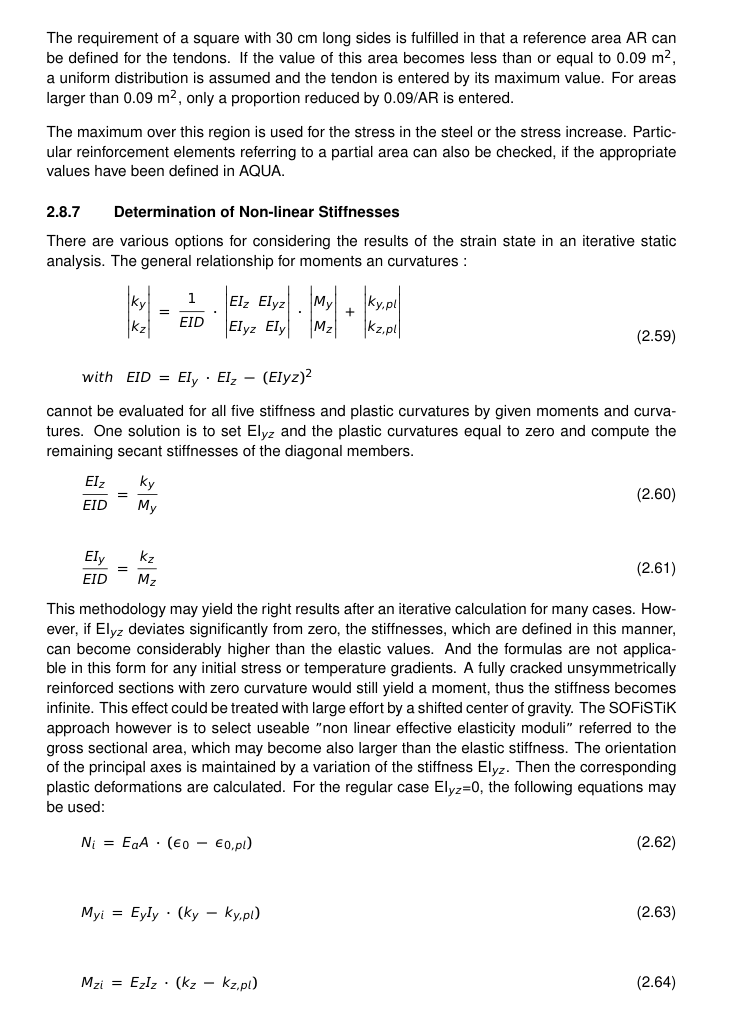

(<PIL.Image.Image image mode=RGB size=730x1022>,
 Pixmap(DeviceRGB, (52, 69, 782, 1091), 0))

In [10]:
# rect = pymupdf.Rect(config['pdf_partition_config']['crop'])
rect = pymupdf.Rect(38, 50, 563, 785)  # A4 size in points

rect
page = doc[40]

render_page(page, rect, dpi=100)

In [11]:
partitions = load_partitions(output_path / 'unstructured_partitions_hi_res.json')

len(partitions)

2740

In [12]:
crop = np.array(config.crop)

In [13]:
partitions = crop_partitions(partitions, doc, crop)

len(partitions)

2132

In [14]:
with open(output_path / 'document_chunks.json', 'r', encoding='utf-8') as f:
    data = json.load(f)

In [15]:
sections = []
for item in data:
    if not item['sections'] is sections:
        print(item['sections'][-1])

    sections = item['sections']


Foreword
Foreword
Foreword
Foreword
Foreword
1 Task Description
1 Task Description
2.1.1 Coordinate System
2.1.1 Coordinate System
2.1.2 External Forces and Moments
2.2.1 Method of Stress Analysis
2.2.3 Limit Stresses
2.2.3 Limit Stresses
2.3.1 Section Classes
2.3.1 Section Classes
2.3.1 Section Classes
2.3.1 Section Classes
2.3.2 Utilisation Levels
2.3.2 Utilisation Levels
2.3.2 Utilisation Levels
2.3.2 Utilisation Levels
2.3.3 Buckling Limit
2.3.4 Special Treatment of EN 1999
2.4 Secondary Stresses (Creep and Construction Stages)
2.4 Secondary Stresses (Creep and Construction Stages)
2.4.1 Shrinkage
2.4.1 Shrinkage
2.4.2 Creep
2.4.2 Creep
2.4.2 Creep
2.4.4 Numerical Treatment
2.6.1 Longitudinal Reinforcement
2.6.1 Longitudinal Reinforcement
2.6.1 Longitudinal Reinforcement
2.6.1 Longitudinal Reinforcement
2.6.2 Min. Reinforcement of the Statically Required Cross Section
2.6.3 Longitudinal reinforcments from transverse and torsional shear
2.6.3 Longitudinal reinforcments from transver

In [16]:
len(data)

243

In [17]:
# save_images(partitions, data, doc, output_path / 'images')

In [18]:
scale = page.rect.width / 3308

scale

0.17995042351165735

In [19]:
p0 = np.array([532.7611111111111, 516.2418212890625]) * scale
p1 = np.array([2950.27783203125, 1596.712158203125]) * scale

rect = pymupdf.Rect(p0.tolist(), p1.tolist())
rect

Rect(95.87058757498558, 92.89793437539613, 530.9037453510778, 287.3290290948648)

In [20]:
page = doc[19]

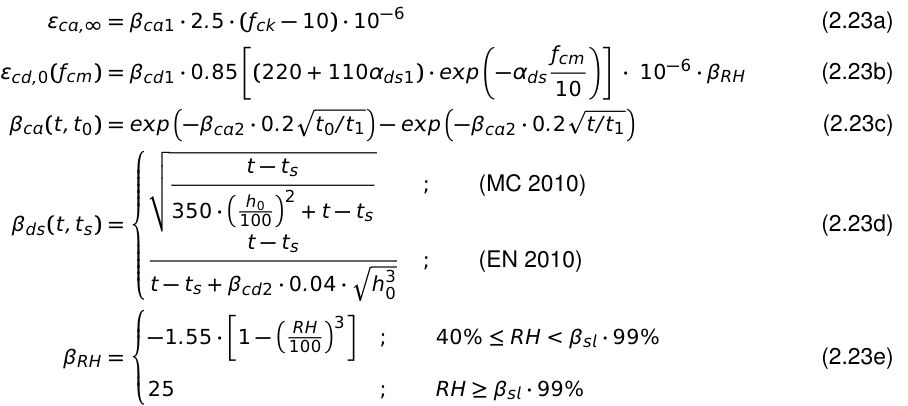

In [21]:
image, pix = render_page(page, rect, dpi=150)

In [22]:
from openai import OpenAI
client = OpenAI()

In [23]:
import base64

image_b64 = base64.b64encode(pix.tobytes()).decode('utf-8')

In [24]:
response = client.responses.create(
    model='gpt-4.1',
    input=[
        {
            "role": "user",
            "content": [
                { 
                    "type": "input_text", 
                    "text": "Write down the equation(s) in LaTeX format:" 
                },
                {
                    "type": "input_image",
                    "image_url": f"data:image/png;base64,{image_b64}",
                },
            ],
        }
    ],
)

In [25]:
response.output_text

'Here are the equations from the image in LaTeX format:\n\n```latex\n\\begin{align}\n\\varepsilon_{ca,\\infty} &= \\beta_{ca1} \\cdot 2.5 \\cdot (f_{ck}-10) \\cdot 10^{-6} \\tag{2.23a} \\\\\n\\varepsilon_{cd,0}(f_{cm}) &= \\beta_{cd1} \\cdot 0.85 \\left[ 220 + 110\\alpha_{ds1} \\right] \\cdot \\exp\\left(-\\alpha_{ds} \\frac{f_{cm}}{10}\\right) \\cdot 10^{-6} \\cdot \\beta_{RH} \\tag{2.23b} \\\\\n\\beta_{ca}(t, t_0) &= \\exp\\left( -\\beta_{ca2} \\cdot 0.2\\sqrt{t_0/t_1} \\right) - \\exp\\left( -\\beta_{ca2} \\cdot 0.2\\sqrt{t/t_1} \\right) \\tag{2.23c} \\\\\n\\beta_{ds}(t, t_s) &=\n\\begin{cases}\n\\sqrt{\\frac{t-t_s}{350 \\cdot \\left(\\frac{h_0}{100}\\right)^2 + t - t_s}} & ; \\quad \\text{(MC 2010)} \\\\\n\\frac{t-t_s}{t-t_s + \\beta_{cd2} \\cdot 0.04 \\cdot \\sqrt{h_0^3}} & ; \\quad \\text{(EN 2010)}\n\\end{cases} \\tag{2.23d} \\\\\n\\beta_{RH} &=\n\\begin{cases}\n-1.55 \\cdot \\left[ 1 - \\left(\\frac{RH}{100}\\right)^3 \\right] & ; \\quad 40\\% \\leq RH < \\beta_{sl} \\cdot 99\\

import pymupdf4llm

pymupdf4llm.to_markdown(
    doc=pdf_path / 'ns-en-1995-1-1_2004+a2_2014+na_2024_en_001.pdf',
    page_chunks=True,
    show_progress=True,
    hdr_info=True,
    write_images=True,
    image_path='output_images',
    embed_images=False,
    force_text=False
)

In [26]:
images = [data for data in data if data['type'] == 'image']

In [27]:
fig = images[1]
coords = np.asarray(fig['coordinates'])

fig['page_indices'], coords[0,:], coords[1,:], fig['height'], fig['width']

([13],
 array([703.81878662, 399.81973267]),
 array([1995.26212333, 1482.88824556]),
 4678,
 3308)

In [28]:
page = doc[fig['page_indices'][0]]

In [29]:
scale = page.rect.width / fig['width']
coords = coords * scale
coords[0,0] = 52
coords[1,0] = 772

rect = pymupdf.Rect(coords[0,:].tolist(), coords[1,:].tolist())

rect

Rect(52.0, 71.94773022156714, 772.0, 266.84636780818084)

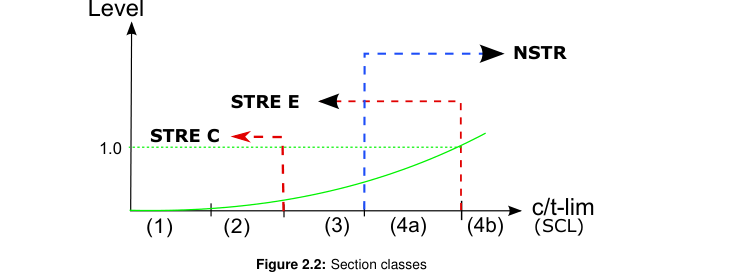

In [30]:
image, pix = render_page(page, rect)

In [63]:
for sections, chunks in iter_by_sections(data):
    print(sections)

Foreword
1 Task Description
2.1.1 Coordinate System
2.1.2 External Forces and Moments
2.2.1 Method of Stress Analysis
2.2.3 Limit Stresses
2.3.1 Section Classes
2.3.2 Utilisation Levels
2.3.3 Buckling Limit
2.3.4 Special Treatment of EN 1999
2.4 Secondary Stresses (Creep and Construction Stages)
2.4.1 Shrinkage
2.4.2 Creep
2.4.4 Numerical Treatment
2.6.1 Longitudinal Reinforcement
2.6.2 Min. Reinforcement of the Statically Required Cross Section
2.6.3 Longitudinal reinforcments from transverse and torsional shear
2.6.4 Structured Sections
2.6.5 Unreinforced Cross Sections
2.6.6 Tendons
2.7 Shear Design
2.7.1 Difference of the Longitudinal Forces
2.7.4 Shear Checks in Circular Cross Sections
2.8.1 General Principles
2.8.2 Non effective plates (Sections of Class 4)
2.8.3 Strain Check
2.8.4 Stress Range of the Reinforcement
2.8.5 Crack Width Check
2.8.7 Determination of Non-linear Stiffnesses
2.8.8 Interaction between Shear and Axial Stresses
2.9.3 Fatigue according to DIN 15018 / DS 804
